<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/DS-AI-Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHASE 4 (EDA)**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving freshretailnet_city_03_dataset.csv to freshretailnet_city_03_dataset.csv


In [ ]:
print("\n--- [4/5] Đang kiểm tra độ chính xác trên tập dữ liệu Test ---")
# Thực hiện dự báo trên tập Test
Y_pred = multi_target_model.predict(X_test)
Y_pred_df = pd.DataFrame(Y_pred, columns=operating_hours_names)

# Tính toán sai số Hamming Loss (Tỷ lệ dự đoán sai trên toàn bộ ma trận dữ liệu)
h_loss = hamming_loss(Y_test, Y_pred)
accuracy_matrix = 1 - h_loss

print("\n================ KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH KHUNG 6H - 22H ================")
print(f"Tổng số ca kiểm tra (Dòng dữ liệu tập Test): {len(X_test)}")
print(f"Độ chính xác tổng thể trên toàn ma trận giờ: {accuracy_matrix*100:.2f}%")
print("------------------------------------------------------------------------")
print("Độ chính xác chi tiết tại một số mốc giờ cốt lõi trong ngày:")
for h in [7, 12, 17, 21]:
    acc = accuracy_score(Y_test[f'hour_{h}'], Y_pred_df[f'hour_{h}'])
    print(f"  - Khung giờ cao điểm {h}h00: {acc*100:.2f}%")
print("========================================================================")

--- Starting In-depth EDA ---
1. Descriptive Statistics for Numerical Columns:
         sale_amount  stock_hour6_22_cnt       discount   holiday_flag  \
count  238320.000000       238320.000000  238320.000000  238320.000000   
mean        0.679249            3.609617       0.915436       0.344444   
std         0.607614            5.491875       0.122586       0.475188   
min         0.000000            0.000000       0.000000       0.000000   
25%         0.300000            0.000000       0.847000       0.000000   
50%         0.600000            0.000000       1.000000       0.000000   
75%         0.900000            6.000000       1.000000       1.000000   
max        10.000000           16.000000       1.000000       1.000000   

       activity_flag         precpt  avg_temperature   avg_humidity  \
count  238320.000000  238320.000000    238320.000000  238320.000000   
mean        0.337240       0.999300        22.610451      40.609608   
std         0.472769       0.744355      

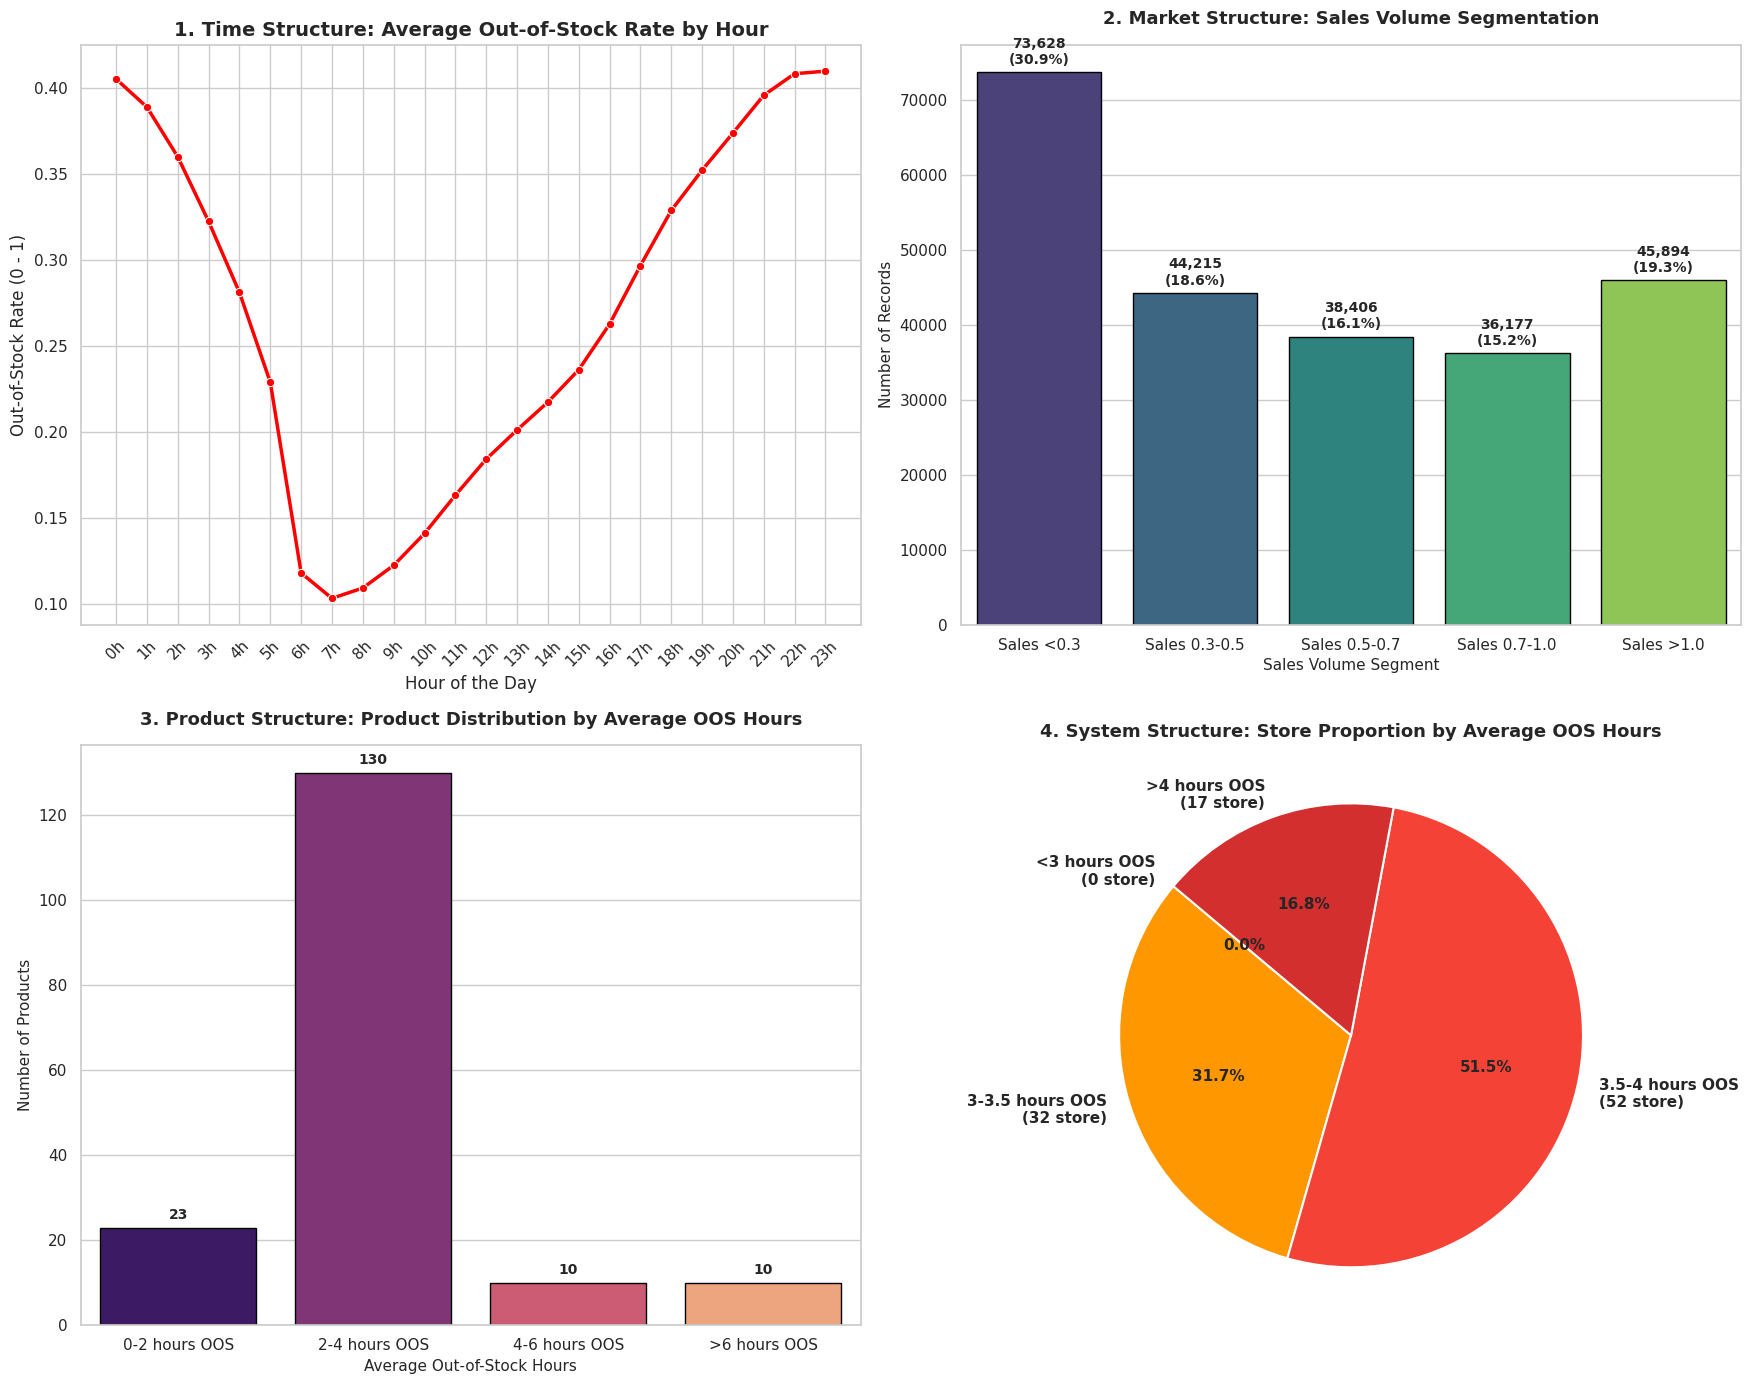

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = df_city_3.copy()

df['dt'] = pd.to_datetime(df['dt'])
df['day_of_week'] = df['dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

def safe_eval(x):
    try: return ast.literal_eval(x)
    except: return [0]*24

df['hours_stock_status'] = df['hours_stock_status'].apply(safe_eval)

hours_df = pd.DataFrame(df['hours_stock_status'].tolist(), columns=[f'{i}h' for i in range(24)])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

hourly_oos_rate = hours_df.mean()
sns.lineplot(x=hourly_oos_rate.index, y=hourly_oos_rate.values, marker='o', color='red', linewidth=2.5, ax=axes[0, 0])
axes[0, 0].set_title('1. Time Structure: Average Out-of-Stock Rate by Hour', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour of the Day')
axes[0, 0].set_ylabel('Out-of-Stock Rate (0 - 1)')
axes[0, 0].tick_params(axis='x', rotation=45)

sale_bins = [-1, 0.3, 0.5, 0.7, 1.0, np.inf]
sale_labels = ['Sales <0.3', 'Sales 0.3-0.5', 'Sales 0.5-0.7', 'Sales 0.7-1.0', 'Sales >1.0']
df['sale_segment'] = pd.cut(df['sale_amount'], bins=sale_bins, labels=sale_labels)

segment_counts = df['sale_segment'].value_counts().reindex(sale_labels)

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette='viridis',
    hue=segment_counts.index,
    legend=False,
    edgecolor='black',
    ax=axes[0, 1]
)

for i, val in enumerate(segment_counts.values):
    percentage = (val / len(df)) * 100
    axes[0, 1].text(i, val + (max(segment_counts.values)*0.01), f'{val:,}\n({percentage:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0, 1].set_title('2. Market Structure: Sales Volume Segmentation', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Sales Volume Segment', fontsize=11)
axes[0, 1].set_ylabel('Number of Records', fontsize=11)

product_oos = df.groupby('product_id')['stock_hour6_22_cnt'].mean().reset_index()

product_oos_bins = [-0.1, 2.0, 4.0, 6.0, np.inf]
product_oos_labels = ['0-2 hours OOS', '2-4 hours OOS', '4-6 hours OOS', '>6 hours OOS']

product_oos['oos_segment'] = pd.cut(product_oos['stock_hour6_22_cnt'], bins=product_oos_bins, labels=product_oos_labels)

product_segment_counts = product_oos['oos_segment'].value_counts().reindex(product_oos_labels, fill_value=0)

sns.barplot(
    x=product_segment_counts.index,
    y=product_segment_counts.values,
    palette='magma',
    hue=product_segment_counts.index,
    legend=False,
    edgecolor='black',
    ax=axes[1, 0]
)

for i, val in enumerate(product_segment_counts.values):
    axes[1, 0].text(i, val + (max(product_segment_counts.values)*0.01), f'{val:,}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 0].set_title('3. Product Structure: Product Distribution by Average OOS Hours', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Average Out-of-Stock Hours', fontsize=11)
axes[1, 0].set_ylabel('Number of Products', fontsize=11)

avg_oos_per_store = df.groupby('store_id')['stock_hour6_22_cnt'].mean()

bins = [0.1, 3.0, 3.5, 4.0, np.inf]
labels = ['<3 hours OOS', '3-3.5 hours OOS', '3.5-4 hours OOS', '>4 hours OOS']
avg_oos_per_store_binned = pd.cut(avg_oos_per_store, bins=bins, labels=labels, right=True)

pie_data = avg_oos_per_store_binned.value_counts().reindex(labels, fill_value=0)

colors = ['#ffeb3b', '#ff9800', '#f44336', '#d32f2f']

axes[1, 1].pie(
    pie_data.values,
    labels=[f"{label}\n({val} store)" for label, val in zip(pie_data.index, pie_data.values)],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1, 1].set_title('4. System Structure: Store Proportion by Average OOS Hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()